In [53]:
# General imports
import pandas as pd
import numpy as np
import itertools
import math
from tqdm import tqdm

# Import custom LIF SNN implementation
from LIF_SNN_network import SNNLayer

# Set random seed for reproducability
np.random.seed(42)

**Test data**

In [54]:
spiketrains = pd.read_csv("Frame_test_spiketrains.csv")

test_dist_train = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 
                   0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
                   0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

test_obj_req = [
    [0, 0, 0],  # 0
    [0, 0, 0],  # 1
    [0, 0, 0],  # 2
    [0, 0, 0],  # 3
    [0, 0, 0],  # 4
    [0, 0, 0],  # 5
    [0, 0, 0],  # 6
    [0, 0, 0],  # 7
    [0, 0, 0],  # 8
    [0, 0, 0],  # 9
    [0, 0, 0],  # 10
    [0, 0, 0],  # 11
    [0, 0, 0],  # 12
    [0, 0, 0],  # 13
    [0, 0, 0],  # 14
    [1, 0, 0],  # 15 - Object detected LEFT
    [1, 0, 0],  # 16
    [1, 0, 0],  # 17
    [1, 0, 0],  # 18
    [1, 0, 0],  # 19
    [1, 0, 0],  # 20
    [1, 0, 0],  # 21
    [1, 0, 0],  # 22
    [1, 0, 0],  # 23
    [1, 0, 0],  # 24
    [0, 1, 0],  # 25 - Object detected CENTRE
    [0, 1, 0],  # 26
    [0, 1, 0],  # 27
    [0, 1, 0],  # 28
    [0, 1, 0],  # 29
    [0, 1, 0],  # 30
    [0, 1, 0],  # 31
    [0, 0, 1],  # 32 - Object detected RIGHT
    [0, 0, 1],  # 33
    [0, 0, 1],  # 34
    [0, 0, 1],  # 35
    [0, 0, 1],  # 36 
    [0, 0, 1],  # 37
    [0, 0, 1],  # 38
    [0, 0, 1],  # 39
    [0, 1, 1],  # 40 - Object detected CENTRE again
    [0, 1, 0],  # 41
    [0, 1, 0],  # 42
    [0, 1, 0],  # 43
    [0, 1, 0],  # 44
    [0, 1, 0],  # 45
    [0, 1, 0],  # 46
    [0, 1, 0],  # 47
    [0, 1, 0],  # 48
    [0, 1, 0],  # 49
]

correct_outputs = []
for i in range(len(test_obj_req)):
    obj_l, obj_c, obj_r = test_obj_req[i]
    
    if obj_r:
        correct_outputs.append(2)      # object right → turn right
    elif obj_l:
        correct_outputs.append(0)      # object left → turn left
    elif obj_c or test_dist_train[i]:
        correct_outputs.append(1)      # object center or close → forward
    else:
        correct_outputs.append(1)      # nothing → forward/explore

input_spikes = []
for i in range(len(spiketrains)):
    row = spiketrains.iloc[i].tolist() + [test_dist_train[i]] + test_obj_req[i]
    input_spikes.append(row)

# Test dataset
test_df = pd.read_csv("Test_full_inputs.csv")
test_dataset = [list(map(int, row.tolist())) for _, row in test_df.iterrows()]

test_correct_outputs = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1]

**Parameters**

In [55]:
# Input/Output size
n_inputs = 16
n_outputs = 3

# Training params
n_epochs = 50
n_runs = 5

# Neuron hyperparameters
decay_range = [0.75]
threshold_range = [4.0]
reset_range = [0.0]

# Synapse parameters
learning_rate_range = [0.125]
initial_weight_range = [0.3]
t_pre_range = [2]
t_post_range = [3]
tau_e_shift_range = [4]
dw_pos_range = [0.25]
dw_neg_range = [0.03125]
min_weight_range = [0.03125]
max_weight_range = [1.0]
dopamine_correct_range = [0.5]
dopamine_wrong_range = [-1.0]
mode_range = ['rstdp']

In [56]:
# Calculate total combinations and set up all configurations
ranges = [
    decay_range, threshold_range, reset_range, 
    learning_rate_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range, 
    min_weight_range, max_weight_range,
    dopamine_correct_range, dopamine_wrong_range,
    mode_range
]

# Printing the total number of configurations
total_configurations = math.prod(map(len, ranges))
print(f"Number of configurations: ", total_configurations)

Number of configurations:  1


**Logging network activity**

In [57]:
# Initialize history lists
tuning_results = []
mean_run_acc = []
epoch_acc = []
num_correct = 0

**Run hyperparameter tuning**

In [ ]:
for config in tqdm(itertools.product(*ranges), total=total_configurations):
    (decay, threshold, reset, 
     learning_rate, initial_weight, 
     t_pre, t_post, tau_e_shift, 
     dw_pos, dw_neg, 
     min_weight, max_weight, 
     dopamine_correct, dopamine_wrong,
     mode) = config

    neuron_params = {"decay":decay, "threshold":threshold, "reset":reset}
    synapse_params = {"learning_rate": learning_rate, "w_init": initial_weight,
                  "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
                  "dw_pos": dw_pos, "dw_neg": dw_neg,
                  "w_min": min_weight, "w_max": max_weight,
                  "mode": mode}

    all_run_accs = []
    all_runs_test_acc = []

    for r in range(n_runs):
        SNN = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs, 
                       synapse_params=synapse_params, neuron_params=neuron_params)

        epoch_acc = []
        epoch_test_acc = []

        """# Test with imported weights
        SNN.load_weights("weights.mem", 127)"""

        for n in range(n_epochs):
            SNN.reset_state()
            num_correct = 0

            # --- TRAINING ---
            for current_spikes, correct_output in zip(input_spikes, correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                if winner_idx == correct_output:
                    dopamine = dopamine_correct
                    num_correct += 1
                else:
                    dopamine = dopamine_wrong

                SNN.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

            epoch_acc.append(num_correct / len(input_spikes))

            # --- TESTING ---
            SNN.reset_state()
            num_test_correct = 0

            for current_spikes, correct_output in zip(test_dataset, test_correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                if winner_idx == correct_output:
                    num_test_correct += 1

            epoch_test_acc.append(num_test_correct / len(test_dataset))

        all_run_accs.append(np.mean(epoch_acc))
        all_runs_test_acc.append(np.mean(epoch_test_acc))

    tuning_results.append(
        neuron_params | synapse_params | {
            "dopamine_correct": dopamine_correct, 
            "dopamine_wrong": dopamine_wrong, 
            "mean_train_acc": np.mean(all_run_accs),
            "std_train_acc": np.std(all_run_accs),
            "mean_test_acc": np.mean(all_runs_test_acc),
            "std_test_acc": np.std(all_runs_test_acc),
        }
    )

100%|██████████| 1/1 [00:03<00:00,  3.89s/it]


In [59]:
df_tuning_results = pd.DataFrame(tuning_results)
df_tuning_results.to_csv("CSV_results/SNN_hyperparameter_Results.csv", index=False)

In [60]:
# Save weights
weights = SNN.get_weights()
scale = 127  # maps ±1.0 → ±127

weights_int8 = np.clip(weights * scale, -127, 127).astype(np.int8)
with open("weights.mem", "w") as f:
    for w in weights_int8.flatten():
        f.write(f"{int(w) & 0xFF:02X}\n")

Final weights (rows=output neurons, cols=inputs):
[[0.031 0.039 0.047 0.039 0.031 0.102 0.031 0.063 0.197 0.102 0.291 0.299
  0.142 0.181 0.26  0.244]
 [0.055 0.205 0.11  0.063 0.055 0.11  0.126 0.118 0.228 0.118 0.22  0.299
  0.197 0.205 0.189 0.307]
 [0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.354 0.024 0.024 0.906
  0.024 0.291 0.819 0.559]]


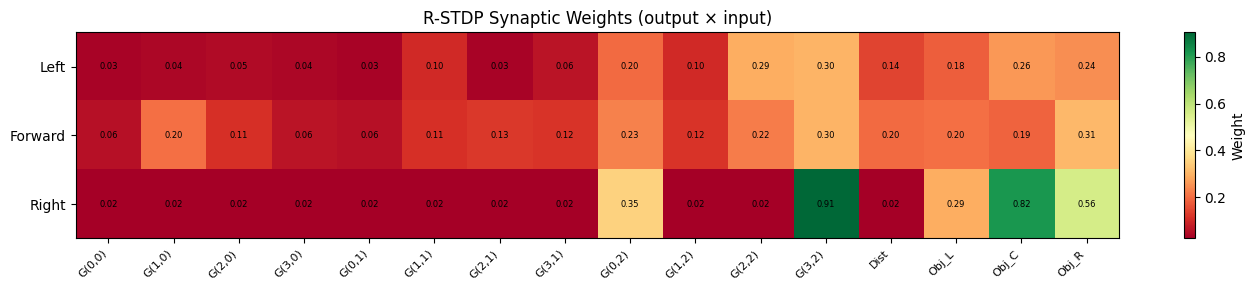

In [61]:
# Print final weights
import numpy as np
weights = SNN.get_weights()
print("Final weights (rows=output neurons, cols=inputs):")
print(np.round(weights, 3))

import numpy as np
import matplotlib.pyplot as plt

weights = SNN.get_weights()  # shape: (3 output neurons, 16 inputs)

# Input labels for 16 inputs
input_labels = [
    'G(0,0)', 'G(1,0)', 'G(2,0)', 'G(3,0)',  # row 0
    'G(0,1)', 'G(1,1)', 'G(2,1)', 'G(3,1)',  # row 1
    'G(0,2)', 'G(1,2)', 'G(2,2)', 'G(3,2)',  # row 2
    'Dist',                                    # ultrasonic
    'Obj_L', 'Obj_C', 'Obj_R'               # object recognition
]
output_labels = ['Left', 'Forward', 'Right']

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(weights, aspect='auto', cmap='RdYlGn')

ax.set_xticks(range(len(input_labels)))
ax.set_xticklabels(input_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(output_labels)))
ax.set_yticklabels(output_labels)
ax.set_title('R-STDP Synaptic Weights (output × input)')

# Annotate cells
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, f'{weights[i,j]:.2f}', ha='center', va='center', fontsize=6)

plt.colorbar(im, ax=ax, label='Weight')
plt.tight_layout()
plt.show()

In [62]:
# Load grid search results
df = pd.read_csv("CSV_results/SNN_hyperparameter_Results.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_test_acc'], ascending=[False]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_test_acc', 'decay', 'threshold', 'w_init', 'reset', 'learning_rate', 'mode', 
              't_pre', 't_post', 'tau_e_shift', 'dw_pos', 'dw_neg',
              'w_min', 'w_max', 'dopamine_correct', 'dopamine_wrong']])

# Parameter impact analysis
print("\n=== Impact of Decay on Accuracy ===")
print(df.groupby('decay')['mean_test_acc'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_test_acc'].mean())

print("\n=== Impact of Learning Rate on Accuracy ===")
print(df.groupby('learning_rate')['mean_test_acc'].mean())

print("\n=== Impact of dw_pos on Accuracy ===")
print(df.groupby('dw_pos')['mean_test_acc'].mean())

print("\n=== Impact of dw_neg on Accuracy ===")
print(df.groupby('dw_neg')['mean_test_acc'].mean())

print("\n=== Impact of tau_e_shift on Accuracy ===")
print(df.groupby('tau_e_shift')['mean_test_acc'].mean())

print("\n=== Impact of w_init on Accuracy ===")
print(df.groupby('w_init')['mean_test_acc'].mean())

# Best overall
print("\n=== Best Overall Config ===")
best = df.sort_values('mean_test_acc', ascending=False).iloc[0]
print(best)

# Worst overall
print("\n=== Worst Overall Config ===")
best = df.sort_values('mean_test_acc', ascending=True).iloc[0]
print(best)

=== Top 25 SNN Configurations ===
   mean_test_acc  decay  threshold  w_init  reset  learning_rate   mode  \
0           0.54   0.75        4.0     0.3    0.0          0.125  rstdp   

   t_pre  t_post  tau_e_shift  dw_pos   dw_neg    w_min  w_max  \
0      2       3            4    0.25  0.03125  0.03125    1.0   

   dopamine_correct  dopamine_wrong  
0               0.5            -1.0  

=== Impact of Decay on Accuracy ===
decay
0.75    0.54
Name: mean_test_acc, dtype: float64

=== Impact of Threshold on Accuracy ===
threshold
4.0    0.54
Name: mean_test_acc, dtype: float64

=== Impact of Learning Rate on Accuracy ===
learning_rate
0.125    0.54
Name: mean_test_acc, dtype: float64

=== Impact of dw_pos on Accuracy ===
dw_pos
0.25    0.54
Name: mean_test_acc, dtype: float64

=== Impact of dw_neg on Accuracy ===
dw_neg
0.03125    0.54
Name: mean_test_acc, dtype: float64

=== Impact of tau_e_shift on Accuracy ===
tau_e_shift
4    0.54
Name: mean_test_acc, dtype: float64

=== Impact of